<a href="https://colab.research.google.com/github/swaroop070305/TASK-TRAINING/blob/main/MINI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)





Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [ ]:
import pandas as pd
df = pd.read_csv(f"{path}/olist_orders_dataset.csv")

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


The month with the highest number of orders is month 8 with 10843 orders.


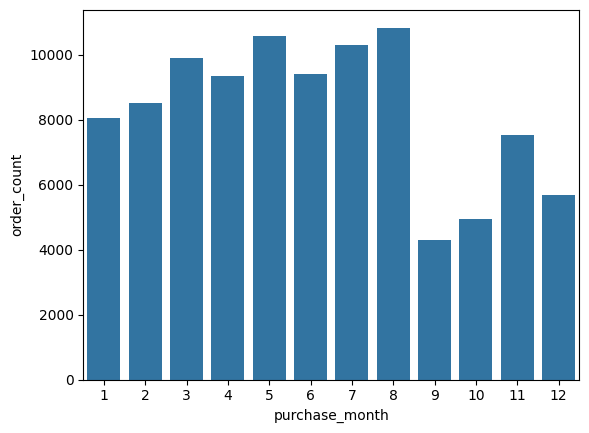

In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
monthly_orders = df.groupby('purchase_month').size().reset_index(name='order_count')
highest_month = monthly_orders.loc[monthly_orders['order_count'].idxmax()]
sns.barplot(x='purchase_month', y='order_count', data=monthly_orders)

print(f"The month with the highest number of orders is month {highest_month['purchase_month']} with {highest_month['order_count']} orders.")

In [ ]:
order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
translation = pd.read_csv(f"{path}/product_category_name_translation.csv")

merged = order_items.merge(products, on='product_id')
merged = merged.merge(translation, on='product_category_name', how='left')

top_categories = (
    merged.groupby('product_category_name_english')
          .size()
          .sort_values(ascending=False)
          .head(10)
)

print(top_categories)



product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
dtype: int64


Top 10 Product Categories by Number of Orders:
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
dtype: int64


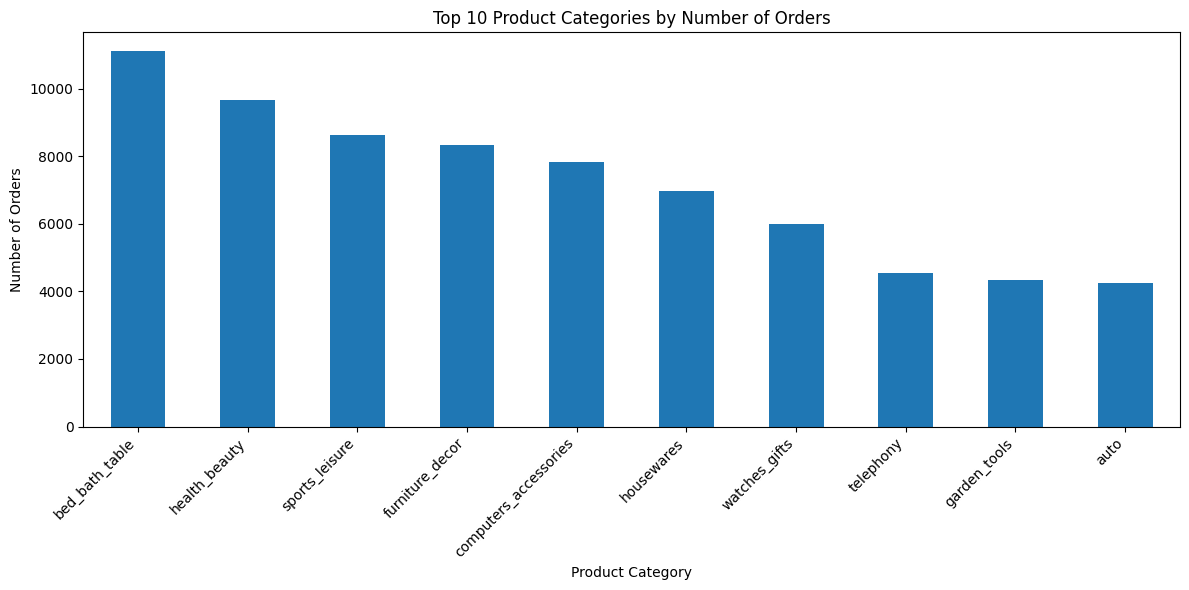

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
translation = pd.read_csv(f"{path}/product_category_name_translation.csv")

# Merge datasets
merged = order_items.merge(products, on='product_id')
merged = merged.merge(translation, on='product_category_name', how='left')

# Top 10 categories by number of orders
top_categories = (
    merged.groupby('product_category_name_english')
          .size()
          .sort_values(ascending=False)
          .head(10)
)

# Print values
print("Top 10 Product Categories by Number of Orders:")
print(top_categories)

# Bar Plot
plt.figure(figsize=(12, 6))
top_categories.plot(kind='bar')

plt.title('Top 10 Product Categories by Number of Orders')
plt.xlabel('Product Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()